# ML044 广义线性模型

这份可运行Notebook连接指数族、Poisson逐行计算、曝光量与条件过度离散。直接先修020、023、029、042至043。先读lecture与lab中的协议，再从空白新核运行全部代码格。所有数据为原创合成数据。

主例三行 x=(-1,0,1)、y=(0,1,3)，曝光量均为1。两次同步更新使用零参数与学习率0.2。输入支持域见正文和experiment.py，不依赖assert进行校验。

In [1]:
# 首物理代码格仅用标准库，先核验固定课程输入及实现。
from pathlib import Path
import hashlib, json, os, sys
ROOT = Path.cwd()
if not (ROOT / 'input_contract.json').is_file():
    raise RuntimeError('请在044目录打开Notebook或先切换工作目录。')
contract = json.loads((ROOT / 'input_contract.json').read_text())
for name, expected in contract.items():
    actual = hashlib.sha256((ROOT / name).read_bytes()).hexdigest()
    if actual != expected:
        raise RuntimeError('输入或实现校验失败: ' + name)
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'outputs/mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(ROOT / 'outputs/cache'))
print('Input contract passed:', len(contract), 'files')

## 1 读取协议和环境

生成协议在任何拟合前固定。true_mean只用于解释，不进入X。不要根据测试指标换种子或删行。

In [2]:
import numpy as np
import scipy, sklearn, matplotlib
import experiment as ex
import plots
from IPython.display import display, Image
protocol = json.loads((ROOT / 'data/protocol.json').read_text())
print(json.dumps(protocol, ensure_ascii=False, indent=2))
print('Python:', sys.version.split()[0], 'NumPy:', np.__version__,
      'SciPy:', scipy.__version__, 'sklearn:', sklearn.__version__, 'Matplotlib:', matplotlib.__version__)

## 2 三个手算状态

预测子η=Xβ+log(e)，均值μ=exp(η)，完整单行loss=μ-yη+log(y!)。局部导数链是(1-y/μ)×μ×(1,x)，最后除以3。先输出旧状态全部行，再同步更新两个参数。

In [3]:
X = np.array([[1.,-1.],[1.,0.],[1.,1.]])
y = np.array([0.,1.,3.])
e = np.ones(3)
beta = np.zeros(2)
hand_states = []
for update in range(3):
    state = ex.state(beta, X, y, e)
    hand_states.append(state)
    print('\nSTATE', update, 'beta=', state['beta'])
    for i in range(3):
        print(json.dumps({name: state[name][i] for name in [
            'eta','mu','loss','d_loss_d_mu','d_mu_d_eta','d_loss_d_eta',
            'd_eta_d_beta','mean_gradient_contributions','hessian_contributions']}, ensure_ascii=False))
    print('Mean loss=', state['mean_loss'], 'gradient=',state['gradient'], 'Hessian=',state['hessian'])
    if update < 2:
        beta = beta - .2*np.array(state['gradient'])

## 3 解析参照与两步尚未收敛

令a=exp(b)、t=exp(w)，得分方程为a/t+a+at=4、at-a/t=3。推出t²-3t-7=0。这条解析参考不依赖优化器。

In [4]:
t = (3 + np.sqrt(37))/2
a = 4/(t+1+1/t)
analytic_beta = np.array([np.log(a), np.log(t)])
small_fit = ex.fit_poisson(X,y,e)
print('analytic beta:',analytic_beta)
print('Newton beta:',small_fit['state']['beta'])
print('status:',small_fit['status'],'updates:',small_fit['updates'])
print('two-update gradient:',hand_states[-1]['gradient'])

## 4 固定模拟全量运行

每种情景320行训练、240行测试。三模型为曝光校正线性、Poisson加offset、Poisson遗漏offset。候选和所有设置均固定，无正则。负预测保留，Poisson deviance不通过夹断或删行补救。

In [5]:
report = ex.scientific_run()
result_path = ex.write_json(ROOT/'outputs/notebook-result.json', report)
for label, case in report['cases'].items():
    print('\nSCENARIO:',label)
    print('test metrics:',json.dumps(case['test_metrics'],ensure_ascii=False,indent=2))
    print('Poisson fit:',case['poisson_fit']['status'],case['poisson_fit']['state']['beta'])
    print('actual sklearn beta:',case['sklearn_beta'])
    print('sklearn beta discrepancy:',case['sklearn_max_abs_beta_difference'])
    print('warnings:',case['sklearn_warnings'])

## 5 曝光单位变换

物理曝光量增为4倍与单位数字增为4倍是不同操作。下格检查仅换单位时，将截距减log(4)使预测不变。

In [6]:
base = ex.state([.2,.4],X,y,e)
changed_unit = ex.state([.2-np.log(4),.4],X,y,4*e)
print('maximum prediction change after unit conversion:',
      np.max(np.abs(np.array(base['mu'])-np.array(changed_unit['mu']))))
print('physical exposure 0.5 -> 2, same beta:',
      2*np.exp(.2)/(.5*np.exp(.2)))

## 6 条件离散度

原始方差还包含不同x和曝光量带来的均值差异。诊断Poisson方差应在条件均值拟合后看残差。Gamma-Poisson保留同一个均值函数，条件方差改为μ+μ²/2。

In [7]:
for label, case in report['cases'].items():
    print(label,'raw variance / mean:',case['raw_train_variance_ddof1']/case['raw_train_mean'],
          'Pearson adjusted dispersion:',case['pearson_dispersion_train'])
for mu in [1,4,10]:
    print('mu=',mu,'Poisson variance=',mu,'Gamma-Poisson variance=',mu+mu**2/2)

## 7 重建原创图并逐幅读图

图由本次真实结果重新生成到outputs，不覆盖交付图。图中的测试散点只在拟合完成后使用。回答每格前的读图问题，再查看正文解释。

In [8]:
figure_paths = plots.make_figures(report,ROOT/'outputs/notebook-figures')
print('Generated',len(figure_paths),'figures')

图1：三个响应函数在η=0的值分别是多少？log与exp哪一个是Poisson链接？

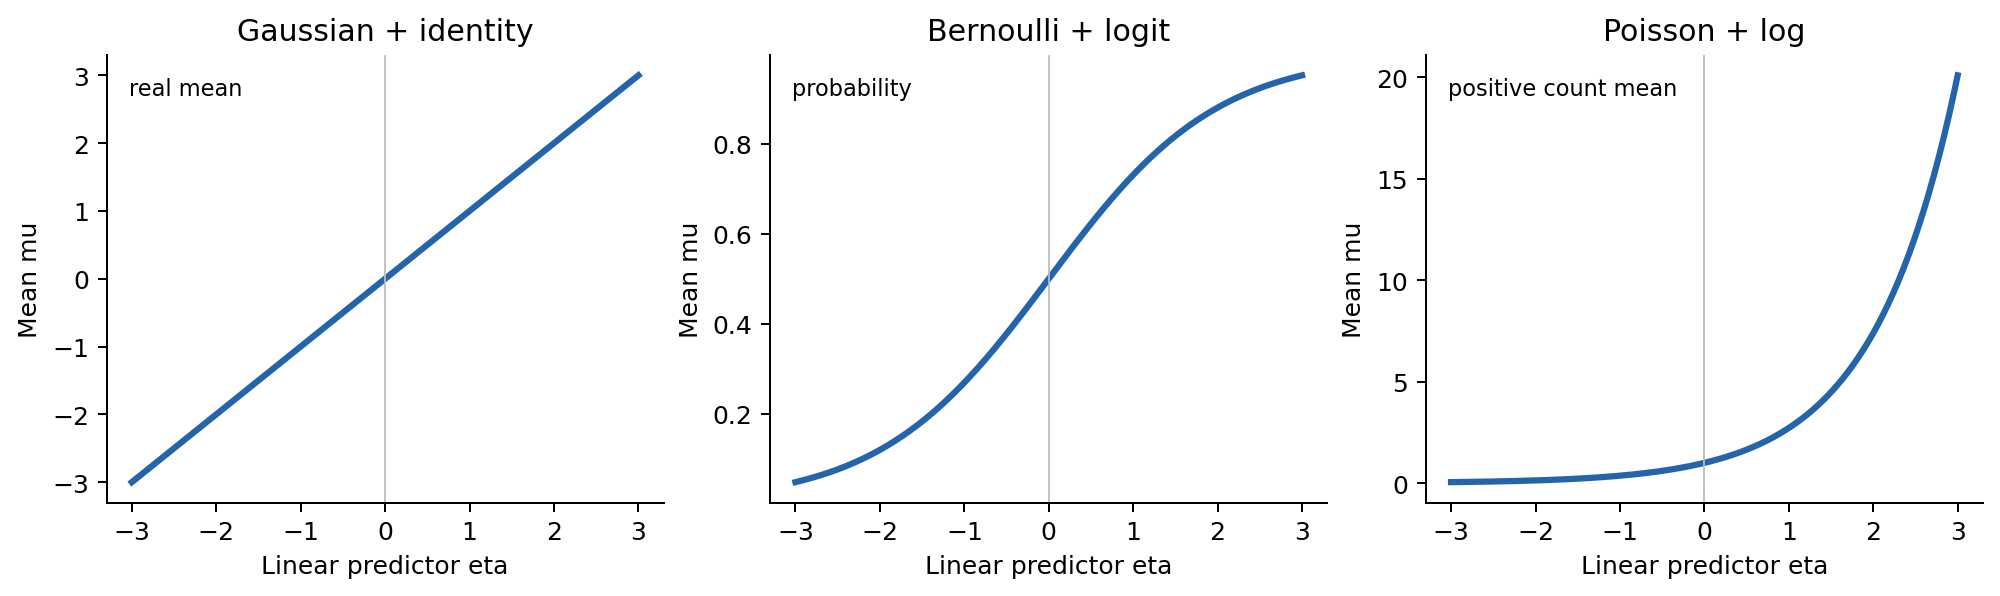

In [9]:
display(Image(filename=figure_paths[0]))

图2：为何计数均值可以为0.5？均值5时的标准差是多少？

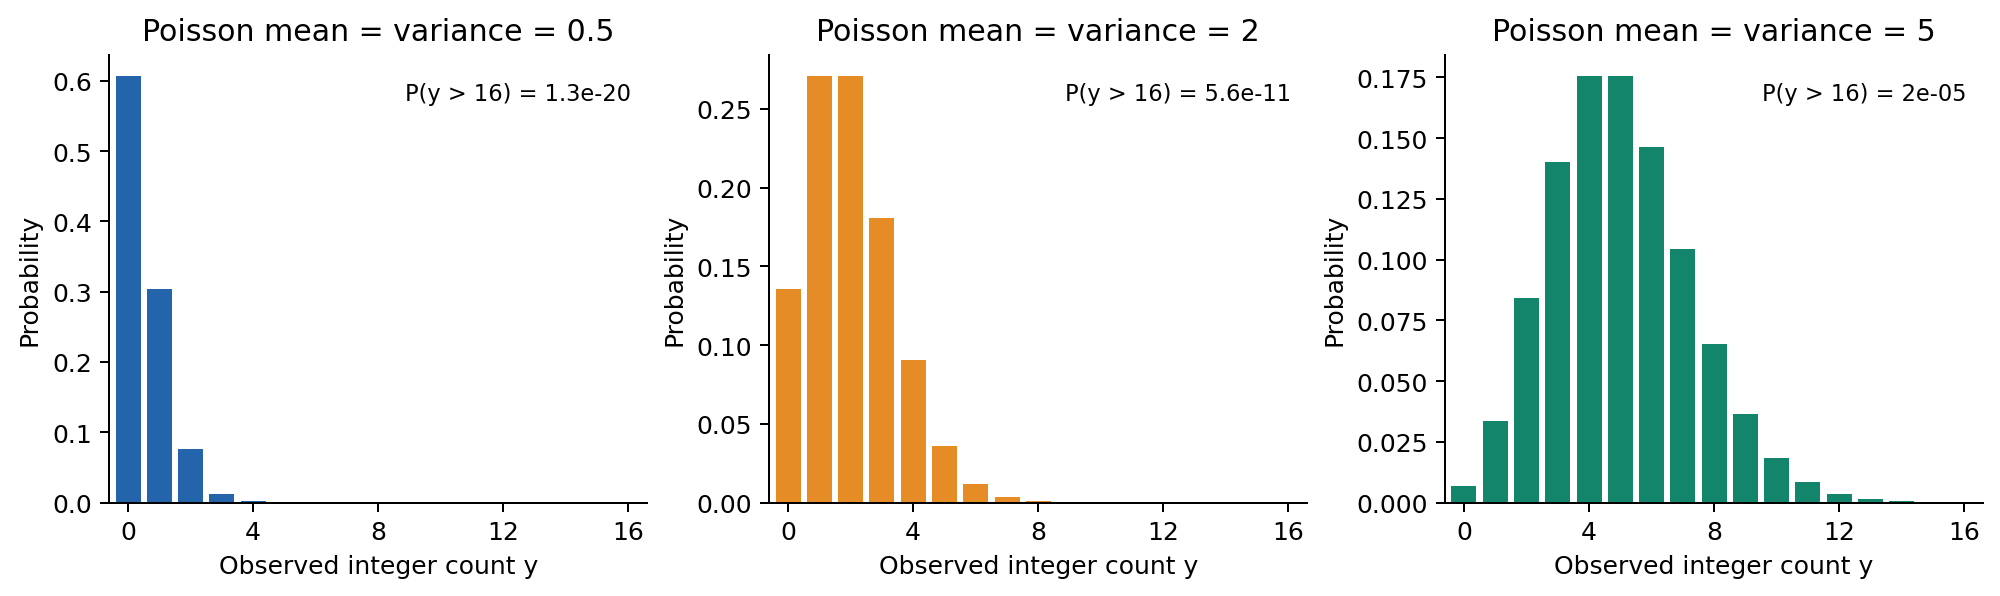

In [10]:
display(Image(filename=figure_paths[1]))

图3：为什么两个更新有三个前向状态？第2行的局部损失是否也下降？

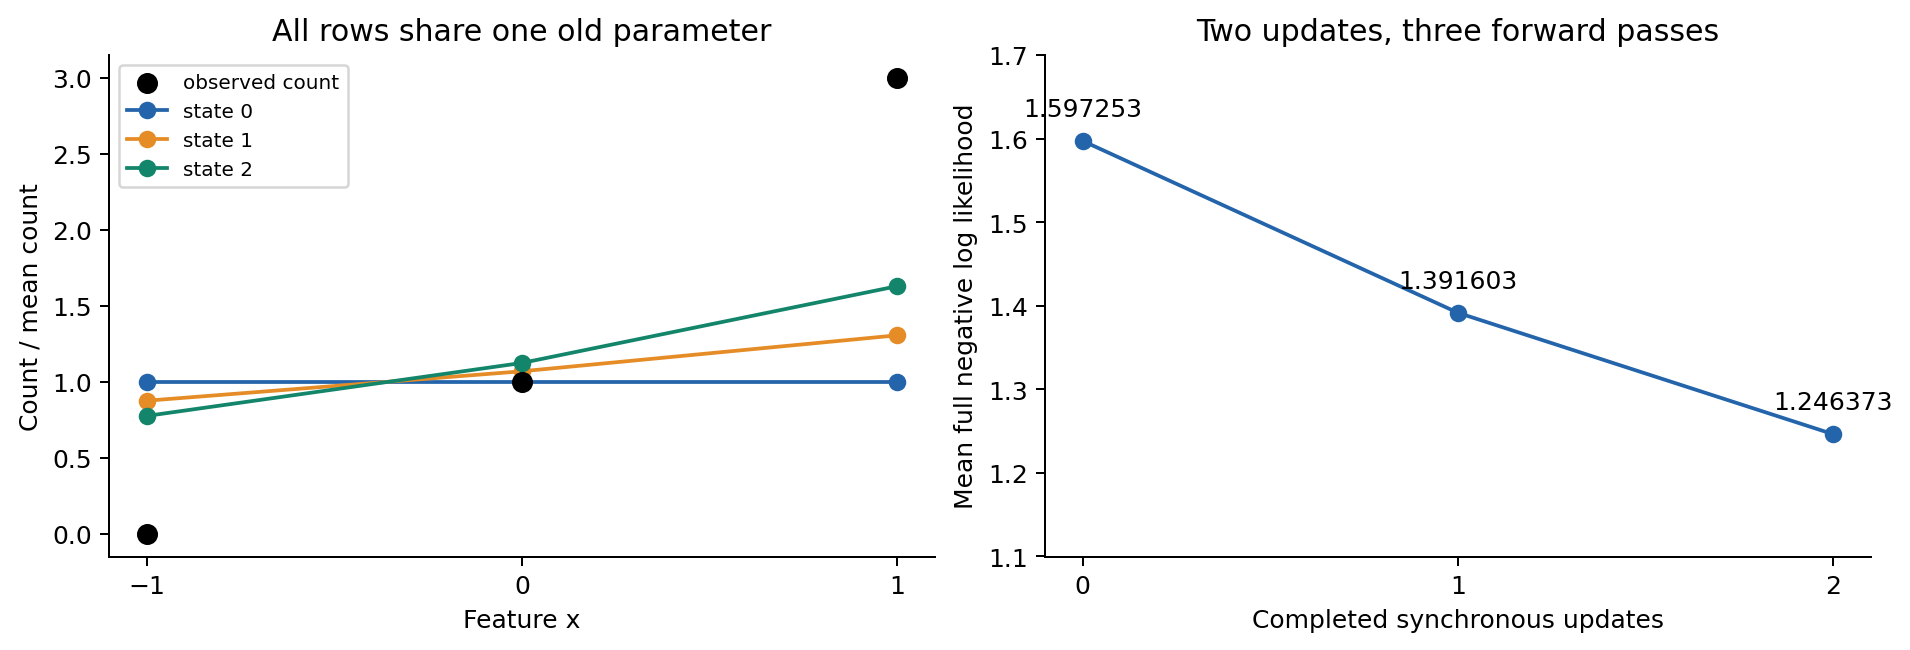

In [11]:
display(Image(filename=figure_paths[2]))

图4：y=0、μ=2的deviance是多少？μ=0的点为何是边界参考？

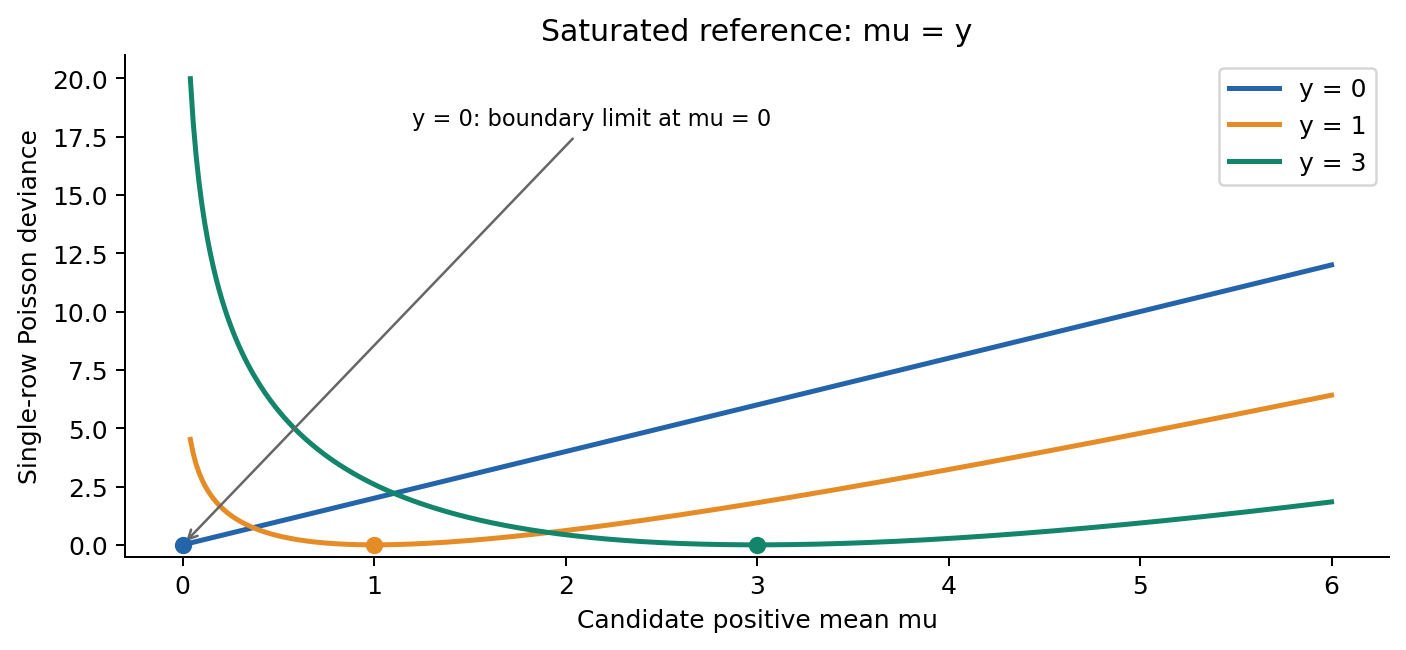

In [12]:
display(Image(filename=figure_paths[3]))

图5：纵轴是率还是次数？线性负预测如何体现在表格中？

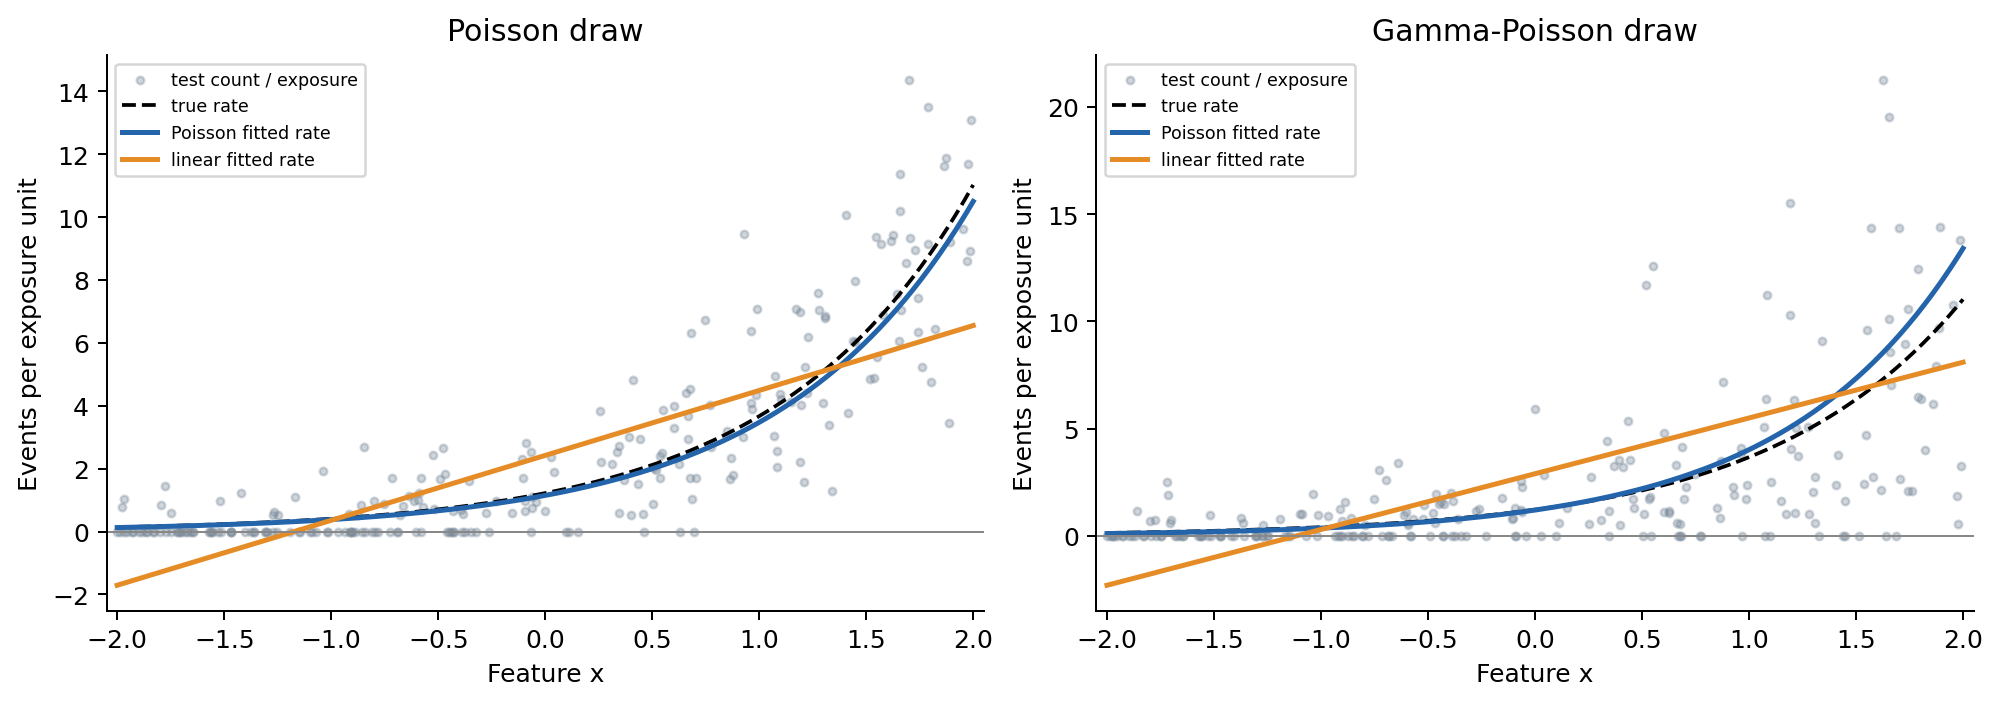

In [13]:
display(Image(filename=figure_paths[4]))

图6：曝光量从0.5变成2，带offset的预测为什么增为4倍？

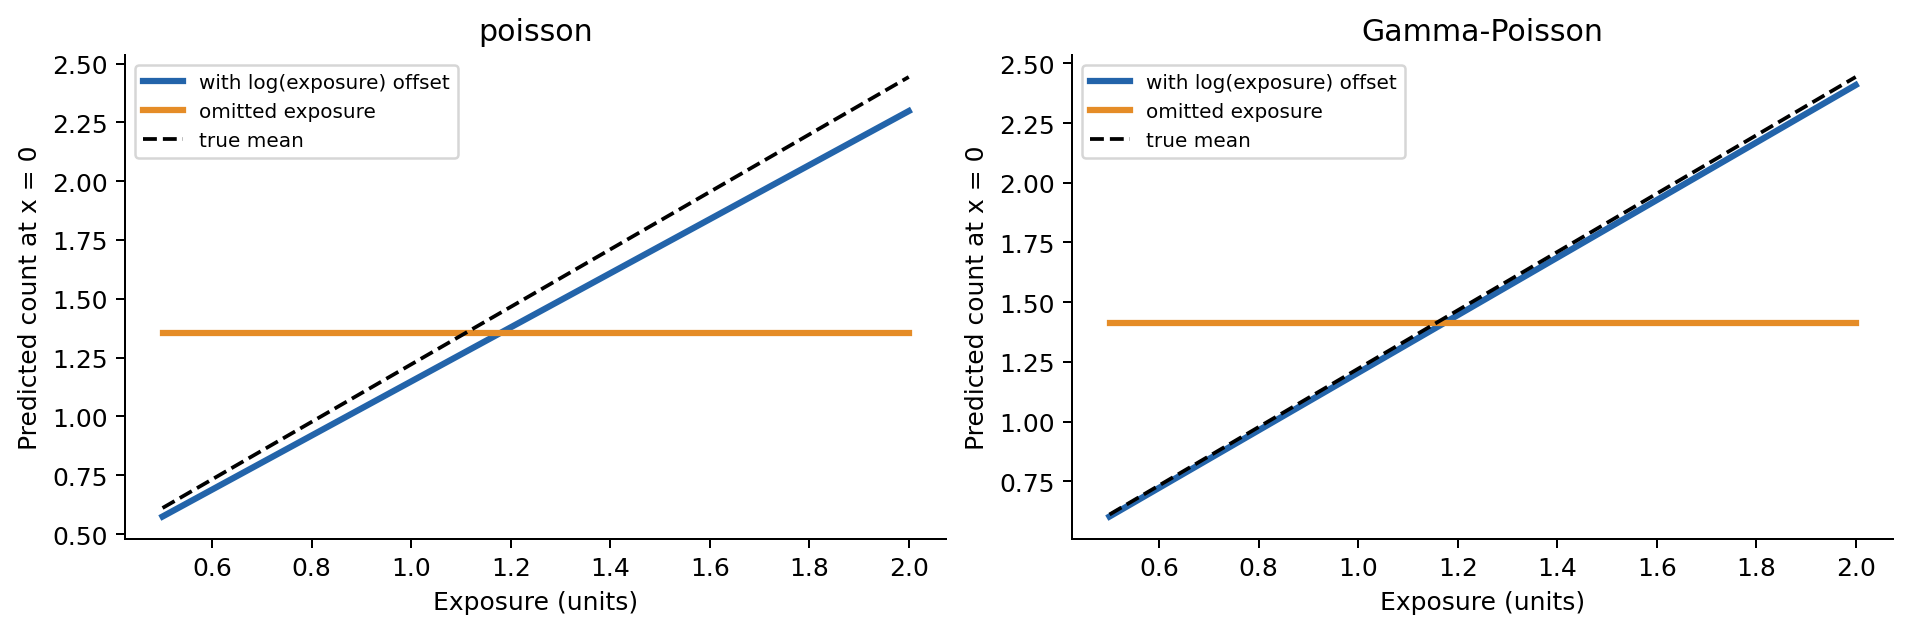

In [14]:
display(Image(filename=figure_paths[5]))

图7：为什么真Poisson数据的原始方差均值比也远大于1？

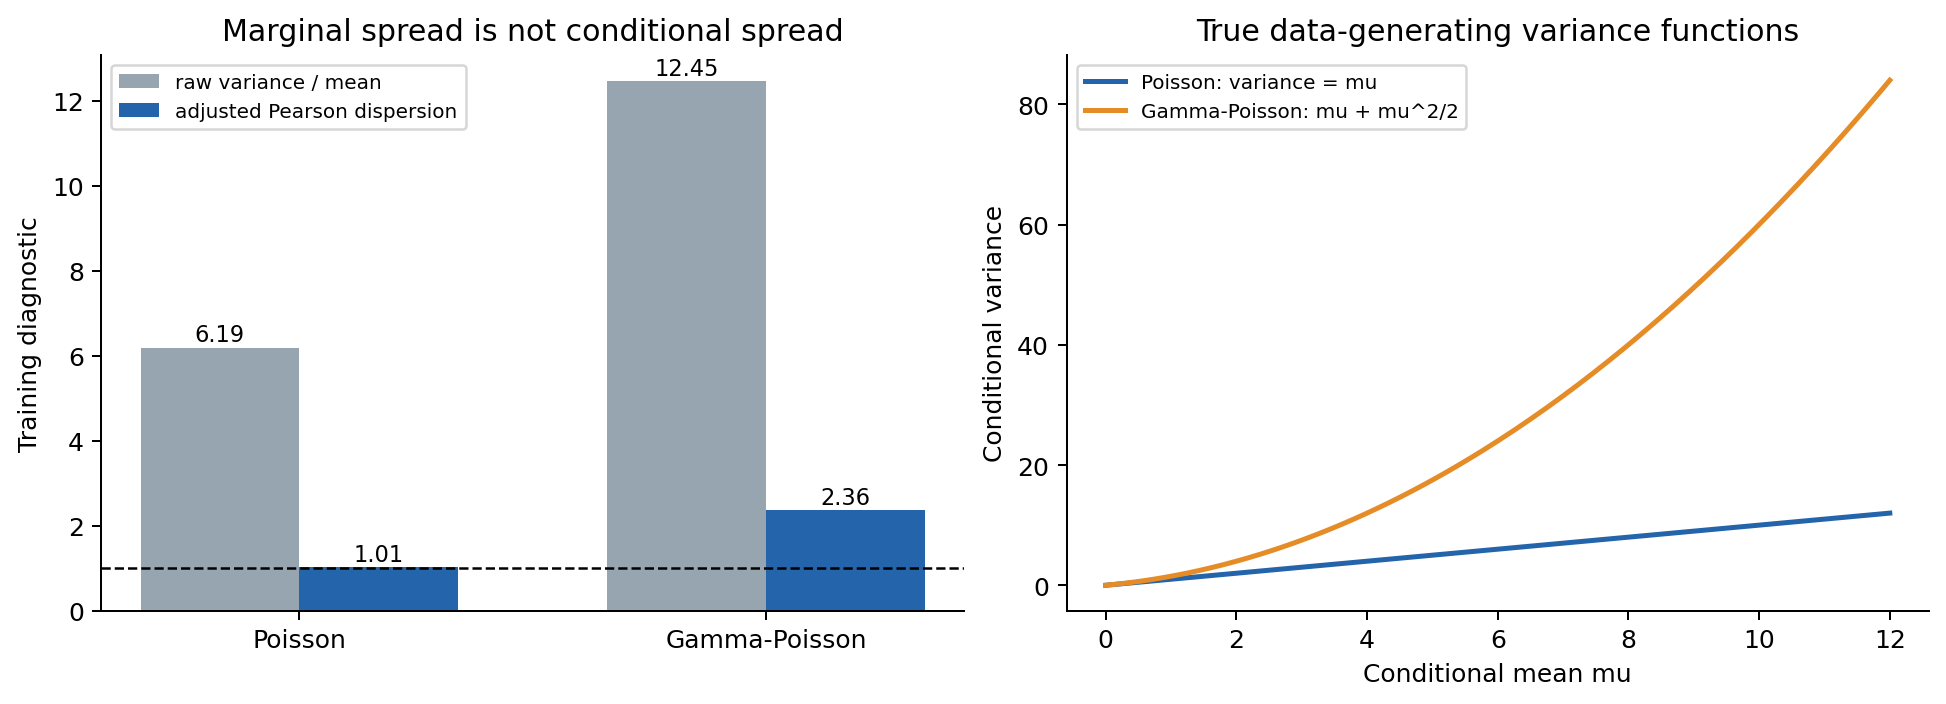

In [15]:
display(Image(filename=figure_paths[6]))

图8：梯度越过停止线，能不能证明Poisson方差假设正确？

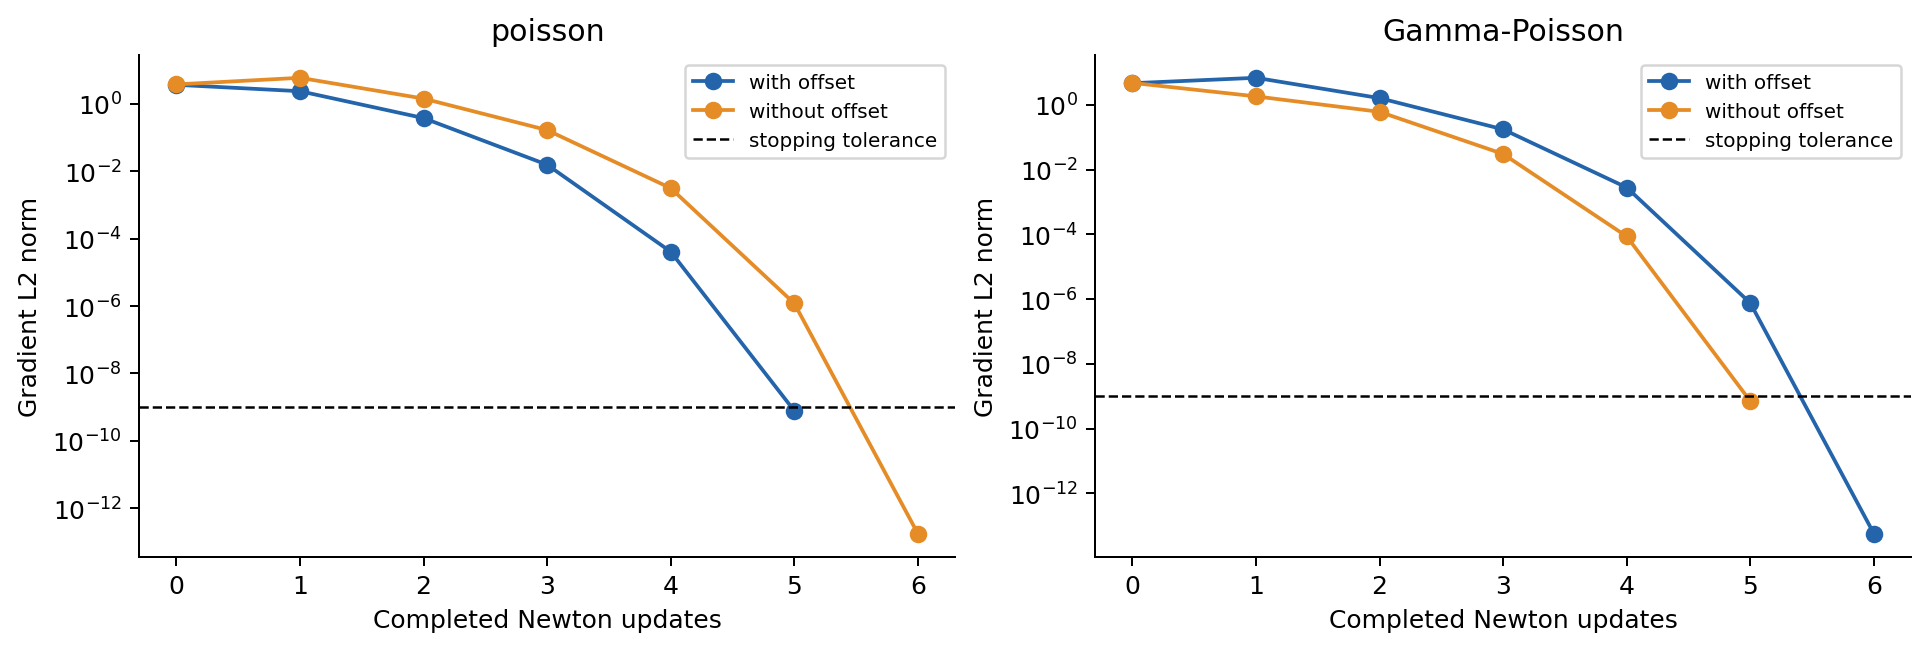

In [16]:
display(Image(filename=figure_paths[7]))

## 8 独立参考与失败路径

下面真正运行80位Decimal、解析MLE、SciPy/sklearn参考与差分检查。作者检查通过不等于独立课程验收。输入错误要主动拒绝，不能取整或夹断来让程序继续。

In [17]:
import audit
audit_result = audit.audit()
print(json.dumps(audit_result,ensure_ascii=False,indent=2))
try:
    ex.state([0,0],X,[0,.5,3],e)
except ValueError as err:
    print('Expected rejection:',str(err))
else:
    raise RuntimeError('fractional count was not rejected')
short_fit = ex.fit_poisson(X,y,e,max_updates=0)
print('Zero-update budget:',short_fit['status'],short_fit['updates'])

## 9 写出你的结论

分别讨论数值公式、优化终止、均值与方差假设、固定模拟的测试表现。保留两种情景所有候选，不依据结果重选种子。完整20题与逐步答案见lecture.md、answers.md；来源范围见source-checks.json。

本Notebook实际使用真实IPython内核顺序执行。受限环境执行器采用新Python进程中的InProcessKernel，不声称验证浏览器Jupyter、socket传输或Windows。